# Day 16 – Student Wellbeing Statistical Analysis & Probability

**Objective:** Perform descriptive statistics, outlier analysis, probability calculations, independence testing, Bayes' theorem, and normal-distribution analysis using the **Student Wellbeing Survey** dataset.

The notebook includes the relevant **formula → Python calculation → numerical result → brief interpretation** for each requested task.

In [1]:
# Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

df = pd.read_csv("Day16_Student_Wellbeing_Survey.csv")

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())


Dataset shape: (600, 20)


,Student_ID,Age,Faculty,Year_of_Study,City,Accommodation,Scholarship,Part_Time_Job,Internet_Quality,Preferred_Study_Space,Weekly_Study_Hours,Average_Sleep_Hours,Daily_Screen_Time_Hours,Exercise_Days_Per_Week,Commute_Time_Minutes,Stress_Score,Academic_Readiness_Score,Overall_Satisfaction,Monthly_Discretionary_Spending,Social_Activity_Hours_Per_Week
0,STU0001,21,Data Science,3,Bengaluru,Hostel,No,Yes,Good,Café,15.2000,5.7000,3.2000,3,11.8000,5.4000,63.1000,3.2000,5131.0000,7.8000
1,STU0002,21,Data Science,4,Pune,Hostel,Yes,No,Poor,Library,17.6000,7.7000,3.5000,4,20.3000,2.1000,74.2000,3.8000,3508.0000,9.2000
2,STU0003,22,Life Sciences,2,Chandigarh,Home,Yes,No,Poor,Home,18.9000,6.4000,2.8000,1,15.0000,5.2000,77.3000,4.0000,4584.0000,7.7000
3,STU0004,18,Business,4,Bengaluru,Hostel,Yes,Yes,Average,Café,19.5000,6.7000,3.0000,5,12.1000,4.7000,67.0000,4.0000,5456.0000,5.3000
4,STU0005,20,Business,3,Jammu,Shared Apartment,Yes,No,Good,Home,18.4000,7.3000,3.0000,1,30.2000,5.4000,65.6000,3.2000,11732.0000,15.9000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Student_ID                      600 non-null    object 
 1   Age                             600 non-null    int64  
 2   Faculty                         600 non-null    object 
 3   Year_of_Study                   600 non-null    int64  
 4   City                            600 non-null    object 
 5   Accommodation                   600 non-null    object 
 6   Scholarship                     600 non-null    object 
 7   Part_Time_Job                   600 non-null    object 
 8   Internet_Quality                600 non-null    object 
 9   Preferred_Study_Space           600 non-null    object 
 10  Weekly_Study_Hours              600 non-null    float64
 11  Average_Sleep_Hours             600 non-null    float64
 12  Daily_Screen_Time_Hours         600 

None

## 1. Dataset Inspection and Data Quality

We first inspect the structure, data types, missing values, duplicate records, and basic descriptive statistics.

In [2]:
# Dataset inspection
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include='all').T)


Column names:
['Student_ID', 'Age', 'Faculty', 'Year_of_Study', 'City', 'Accommodation', 'Scholarship', 'Part_Time_Job', 'Internet_Quality', 'Preferred_Study_Space', 'Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours', 'Exercise_Days_Per_Week', 'Commute_Time_Minutes', 'Stress_Score', 'Academic_Readiness_Score', 'Overall_Satisfaction', 'Monthly_Discretionary_Spending', 'Social_Activity_Hours_Per_Week']

Data types:


,dtype
Student_ID,object
Age,int64
Faculty,object
Year_of_Study,int64
City,object
Accommodation,object
Scholarship,object
Part_Time_Job,object
Internet_Quality,object
Preferred_Study_Space,object



Missing values:


,missing_values
Student_ID,0
Age,0
Faculty,0
Year_of_Study,0
City,0
Accommodation,0
Scholarship,0
Part_Time_Job,0
Internet_Quality,0
Preferred_Study_Space,0



Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,600,600,STU0600,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,600.0000,NaN,NaN,NaN,20.7633,1.7055,17.0000,20.0000,21.0000,22.0000,25.0000
Faculty,600,5,Engineering,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Study,600.0000,NaN,NaN,NaN,2.3883,1.0891,1.0000,1.0000,2.0000,3.0000,4.0000
City,600,8,Delhi,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accommodation,600,4,Home,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,600,2,No,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Part_Time_Job,600,2,No,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Quality,600,4,Good,296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preferred_Study_Space,600,4,Home,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Mean, Median, Mode, Range, Variance, Standard Deviation, Q1, Q3 and IQR

### Formulas
- **Mean:** $\bar{x}=\frac{\sum x_i}{n}$
- **Median:** middle value after sorting
- **Mode:** most frequently occurring value
- **Range:** $\max(x)-\min(x)$
- **Variance (sample):** $s^2=\frac{\sum(x_i-\bar{x})^2}{n-1}$
- **Standard deviation:** $s=\sqrt{s^2}$
- **IQR:** $Q3-Q1$

The variable with the largest **standard deviation** is treated as having the greatest absolute variability.

In [3]:
# Descriptive statistics for the five required variables
stats_vars = ['Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours', 'Stress_Score', 'Academic_Readiness_Score']

rows = []
for col in stats_vars:
    s = df[col].dropna()
    mode_values = s.mode().tolist()
    rows.append({
        "Variable": col,
        "Mean": s.mean(),
        "Median": s.median(),
        "Mode": ", ".join(map(str, mode_values)),
        "Range": s.max() - s.min(),
        "Variance": s.var(),
        "Std_Deviation": s.std(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "IQR": s.quantile(0.75) - s.quantile(0.25)
    })

desc_stats = pd.DataFrame(rows).set_index("Variable")
display(desc_stats)

greatest_variable = desc_stats["Std_Deviation"].idxmax()
greatest_sd = desc_stats.loc[greatest_variable, "Std_Deviation"]

print(f"Variable with greatest absolute variability (highest standard deviation): "
      f"{greatest_variable} (SD = {greatest_sd:.4f})")


,Mean,Median,Mode,Range,Variance,Std_Deviation,Q1,Q3,IQR
Variable,,,,,,,,,
Weekly_Study_Hours,15.6910,15.4000,"13.1, 14.6, 15.3, 17.1",30.0000,19.2170,4.3837,13.0000,18.4250,5.4250
Average_Sleep_Hours,6.9975,7.0000,7.0,5.0000,0.7034,0.8387,6.4750,7.6000,1.1250
Daily_Screen_Time_Hours,4.5030,4.2000,3.5,11.2000,3.4690,1.8625,3.2000,5.4000,2.2000
Stress_Score,4.4645,4.5000,"4.7, 4.9",8.4000,2.7825,1.6681,3.3000,5.7000,2.4000
Academic_Readiness_Score,71.7732,71.6500,"71.1, 71.4, 78.0",56.1000,93.9820,9.6944,65.2000,78.0250,12.8250


Variable with greatest absolute variability (highest standard deviation): Academic_Readiness_Score (SD = 9.6944)


### Interpretation

The table above gives all requested measures. The variable with the highest standard deviation has the greatest **absolute spread** around its mean. For comparing variables measured in different units, the coefficient of variation can additionally be considered, but the assignment's direct variability comparison is based on standard deviation.

## 3. Outlier Detection Using the IQR Method

### Formula
For each variable:
- $IQR=Q3-Q1$
- **Lower fence:** $Q1-1.5(IQR)$
- **Upper fence:** $Q3+1.5(IQR)$
- Any value below the lower fence or above the upper fence is an outlier.

In [4]:
# IQR outlier detection
outlier_vars = ['Weekly_Study_Hours', 'Daily_Screen_Time_Hours', 'Commute_Time_Minutes', 'Monthly_Discretionary_Spending']

outlier_summary = []
outlier_details = {}

for col in outlier_vars:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    values = df.loc[mask, col].dropna()

    outlier_summary.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Fence": lower,
        "Upper_Fence": upper,
        "Outlier_Count": len(values)
    })
    outlier_details[col] = values.tolist()

outlier_table = pd.DataFrame(outlier_summary).set_index("Variable")
display(outlier_table)

for col, values in outlier_details.items():
    print(f"\n{col} outlier values ({len(values)}):")
    print(values if values else "No outliers detected.")


,Q1,Q3,IQR,Lower_Fence,Upper_Fence,Outlier_Count
Variable,,,,,,
Weekly_Study_Hours,13.0000,18.4250,5.4250,4.8625,26.5625,8
Daily_Screen_Time_Hours,3.2000,5.4000,2.2000,-0.1000,8.7000,18
Commute_Time_Minutes,13.3750,31.5250,18.1500,-13.8500,58.7500,4
Monthly_Discretionary_Spending,4113.0000,7808.5000,3695.5000,-1430.2500,13351.7500,20



Weekly_Study_Hours outlier values (8):
[27.8, 26.6, 26.6, 4.0, 27.2, 34.0, 4.3, 27.2]

Daily_Screen_Time_Hours outlier values (18):
[9.8, 10.1, 11.8, 10.4, 12.4, 12.0, 10.6, 11.3, 9.1, 12.0, 10.4, 9.2, 11.0, 11.1, 9.3, 9.0, 12.0, 9.9]

Commute_Time_Minutes outlier values (4):
[65.2, 62.3, 72.5, 118.0]

Monthly_Discretionary_Spending outlier values (20):
[28000.0, 16791.0, 13945.0, 14064.0, 31500.0, 19559.0, 14667.0, 14859.0, 13875.0, 14594.0, 18038.0, 13946.0, 14718.0, 14698.0, 13697.0, 14097.0, 23782.0, 17349.0, 14809.0, 14522.0]


## 4. Mean and Median Before vs After Removing Outliers

We compare the mean and median for **Weekly_Study_Hours** before and after removing its IQR-detected outliers. This shows how extreme observations can affect central tendency.

In [5]:
col = "Weekly_Study_Hours"
s = df[col].dropna()

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

filtered = s[(s >= lower) & (s <= upper)]

comparison = pd.DataFrame({
    "Mean": [s.mean(), filtered.mean()],
    "Median": [s.median(), filtered.median()],
    "Count": [len(s), len(filtered)]
}, index=["Before removing outliers", "After removing outliers"])

display(comparison)

print(f"Lower fence = {lower:.4f}, Upper fence = {upper:.4f}")
print("Interpretation: Compare the mean and median changes. A larger change in the mean "
      "than the median indicates that extreme observations have a stronger effect on the mean.")


,Mean,Median,Count
Before removing outliers,15.6910,15.4000,600
After removing outliers,15.6029,15.3500,592


Lower fence = 4.8625, Upper fence = 26.5625
Interpretation: Compare the mean and median changes. A larger change in the mean than the median indicates that extreme observations have a stronger effect on the mean.


## 5. Probability Events

Define:

- **Event A:** `Part_Time_Job == "Yes"`
- **Event B:** `Stress_Score >= 7`
- **Event C:** `Scholarship == "Yes"`
- **Event D:** student exercises at least 3 days per week

For probability calculations:
- $P(A)=\frac{n(A)}{n}$
- $P(B)=\frac{n(B)}{n}$
- $P(A\ or\ B)=\frac{n(A\cup B)}{n}$
- $P(A\ and\ B)=\frac{n(A\cap B)}{n}$
- $P(A|B)=\frac{P(A\cap B)}{P(B)}$
- $P(B|A)=\frac{P(A\cap B)}{P(A)}$

The exercise column is detected automatically from the dataset so the notebook can handle common names such as `Exercise_Days_Per_Week`.

In [6]:
# Identify the exercise-days column
exercise_candidates = [
    c for c in df.columns
    if ("exercise" in c.lower() or "exercise" in c.lower())
    and ("day" in c.lower() or "week" in c.lower())
]

print("Possible exercise-days columns:", exercise_candidates)

# Prefer the most likely exact column name.
preferred = [c for c in exercise_candidates if c.lower() in [
    "exercise_days_per_week", "exercise_days", "exercise_days_week"
]]
exercise_col = preferred[0] if preferred else exercise_candidates[0]

print("Using exercise column:", exercise_col)

# Define events
A = df["Part_Time_Job"].astype(str).str.strip().str.lower().eq("yes")
B = pd.to_numeric(df["Stress_Score"], errors="coerce").ge(7)
C = df["Scholarship"].astype(str).str.strip().str.lower().eq("yes")
D = pd.to_numeric(df[exercise_col], errors="coerce").ge(3)

valid_ab = A.notna() & B.notna()
n = len(df)

p_A = A.mean()
p_B = B.mean()
p_C = C.mean()
p_D = D.mean()

p_A_or_B = (A | B).mean()
p_A_and_B = (A & B).mean()
p_A_given_B = (A & B).sum() / B.sum()
p_B_given_A = (A & B).sum() / A.sum()

probabilities = pd.DataFrame({
    "Probability": [
        p_A, p_B, p_C, p_D,
        p_A_or_B, p_A_and_B, p_A_given_B, p_B_given_A
    ]
}, index=["P(A)", "P(B)", "P(C)", "P(D)",
          "P(A or B)", "P(A and B)", "P(A | B)", "P(B | A)"])

display(probabilities)

print("Counts:")
print("A:", int(A.sum()), "B:", int(B.sum()), "C:", int(C.sum()), "D:", int(D.sum()))
print("A and B:", int((A & B).sum()))
print("A or B:", int((A | B).sum()))


Possible exercise-days columns: ['Exercise_Days_Per_Week']
Using exercise column: Exercise_Days_Per_Week


,Probability
P(A),0.2533
P(B),0.0750
P(C),0.3067
P(D),0.5933
P(A or B),0.2767
P(A and B),0.0517
P(A | B),0.6889
P(B | A),0.2039


Counts:
A: 152 B: 45 C: 184 D: 356
A and B: 31
A or B: 166


### Probability interpretation

Each probability is the proportion of students satisfying the relevant event. `P(A and B)` measures the joint occurrence of a part-time job and high stress, while `P(A | B)` and `P(B | A)` answer different conditional questions.

## 6. Mutually Exclusive Events: Year 1 and Year 4

Two events are mutually exclusive if they **cannot occur at the same time**.

### Formula
$P(E_1\cap E_4)=0$

A student cannot simultaneously have `Year_of_Study = 1` and `Year_of_Study = 4`, so these events should be mutually exclusive.

In [7]:
year1 = pd.to_numeric(df["Year_of_Study"], errors="coerce").eq(1)
year4 = pd.to_numeric(df["Year_of_Study"], errors="coerce").eq(4)

intersection_count = (year1 & year4).sum()
p_intersection = (year1 & year4).mean()

print("Year 1 students:", int(year1.sum()))
print("Year 4 students:", int(year4.sum()))
print("Year 1 AND Year 4:", int(intersection_count))
print("P(Year 1 AND Year 4):", p_intersection)

if intersection_count == 0:
    print("Conclusion: Year 1 and Year 4 are mutually exclusive events.")
else:
    print("Conclusion: They are not mutually exclusive in the supplied data.")


Year 1 students: 164
Year 4 students: 120
Year 1 AND Year 4: 0
P(Year 1 AND Year 4): 0.0
Conclusion: Year 1 and Year 4 are mutually exclusive events.


## 7. Are A and B Independent?

Events A and B are independent when:

$$P(A\cap B)=P(A)P(B)$$

We compare the observed joint probability with the product of the individual probabilities. A very small difference supports approximate independence; a noticeable difference indicates dependence in the sample.

In [8]:
independence_product = p_A * p_B
difference = p_A_and_B - independence_product

print(f"P(A and B) = {p_A_and_B:.6f}")
print(f"P(A) × P(B) = {independence_product:.6f}")
print(f"Difference = {difference:.6f}")

# A simple relative comparison
relative_difference = abs(difference) / independence_product if independence_product != 0 else np.nan
print(f"Relative difference = {relative_difference:.2%}")

if np.isclose(p_A_and_B, independence_product, atol=1e-3):
    print("Conclusion: A and B appear approximately independent in this sample.")
else:
    print("Conclusion: A and B do not appear independent; the observed joint probability "
          "differs from P(A) × P(B).")


P(A and B) = 0.051667
P(A) × P(B) = 0.019000
Difference = 0.032667
Relative difference = 171.93%
Conclusion: A and B do not appear independent; the observed joint probability differs from P(A) × P(B).


## 8. Bayes' Theorem

Bayes' theorem is:

$$P(A|B)=\frac{P(B|A)P(A)}{P(B)}$$

Also,

$$P(B)=P(B|A)P(A)+P(B|\neg A)P(\neg A)$$

Therefore:

$$P(A|B)=\frac{P(B|A)P(A)}
{P(B|A)P(A)+P(B|\neg A)P(\neg A)}$$

We calculate $P(B|\neg A)$ from students without a part-time job, then verify the result against the direct conditional calculation.

In [9]:
not_A = ~A

p_not_A = not_A.mean()
p_B_given_not_A = (B & not_A).sum() / not_A.sum()

bayes_denominator = p_B_given_A * p_A + p_B_given_not_A * p_not_A
bayes_p_A_given_B = (p_B_given_A * p_A) / bayes_denominator

print(f"P(A) = {p_A:.6f}")
print(f"P(B|A) = {p_B_given_A:.6f}")
print(f"P(B|not A) = {p_B_given_not_A:.6f}")
print(f"P(not A) = {p_not_A:.6f}")
print(f"Bayes denominator P(B) = {bayes_denominator:.6f}")
print(f"P(A|B) using Bayes' theorem = {bayes_p_A_given_B:.6f}")
print(f"P(A|B) direct = {p_A_given_B:.6f}")
print(f"Difference = {abs(bayes_p_A_given_B - p_A_given_B):.12f}")

if np.isclose(bayes_p_A_given_B, p_A_given_B, atol=1e-10):
    print("Verification: Bayes' theorem agrees with the direct conditional probability.")
else:
    print("Verification: The values differ slightly; inspect rounding or missing-value handling.")


P(A) = 0.253333
P(B|A) = 0.203947
P(B|not A) = 0.031250
P(not A) = 0.746667
Bayes denominator P(B) = 0.075000
P(A|B) using Bayes' theorem = 0.688889
P(A|B) direct = 0.688889
Difference = 0.000000000000
Verification: Bayes' theorem agrees with the direct conditional probability.


## 9. Academic Readiness Score and the Normal Distribution

Let $X$ be `Academic_Readiness_Score`.

### Mean and standard deviation
- Mean: $\mu=\bar{x}$
- Standard deviation: $\sigma=s$

### Z-score
$$Z=\frac{X-\mu}{\sigma}$$

A positive Z-score means the score is above the mean; a negative Z-score means it is below the mean. The absolute Z-score indicates how many standard deviations the score is from the mean.

In [10]:
readiness = pd.to_numeric(df["Academic_Readiness_Score"], errors="coerce").dropna()

mu = readiness.mean()
sigma = readiness.std()

highest_idx = readiness.idxmax()
lowest_idx = readiness.idxmin()
highest_score = readiness.loc[highest_idx]
lowest_score = readiness.loc[lowest_idx]

highest_z = (highest_score - mu) / sigma
lowest_z = (lowest_score - mu) / sigma

print(f"Mean (μ) = {mu:.6f}")
print(f"Standard deviation (σ) = {sigma:.6f}")

print("\nHighest Academic Readiness Score:")
print(f"Student/row index = {highest_idx}")
print(f"Score = {highest_score:.6f}")
print(f"Z-score = {highest_z:.6f}")

print("\nLowest Academic Readiness Score:")
print(f"Student/row index = {lowest_idx}")
print(f"Score = {lowest_score:.6f}")
print(f"Z-score = {lowest_z:.6f}")

print(f"\nInterpretation of highest Z-score: the highest score is {abs(highest_z):.2f} "
      f"standard deviations above the mean.")
print(f"Interpretation of lowest Z-score: the lowest score is {abs(lowest_z):.2f} "
      f"standard deviations below the mean.")


Mean (μ) = 71.773167
Standard deviation (σ) = 9.694430

Highest Academic Readiness Score:
Student/row index = 130
Score = 98.000000
Z-score = 2.705351

Lowest Academic Readiness Score:
Student/row index = 542
Score = 41.900000
Z-score = -3.081477

Interpretation of highest Z-score: the highest score is 2.71 standard deviations above the mean.
Interpretation of lowest Z-score: the lowest score is 3.08 standard deviations below the mean.


## 10. 68–95–99.7 Empirical Rule

For a normal distribution:

- Approximately **68%** of observations lie within **±1 standard deviation** of the mean.
- Approximately **95%** lie within **±2 standard deviations**.
- Approximately **99.7%** lie within **±3 standard deviations**.

For Academic Readiness Score, the expected intervals are calculated below.

In [11]:
empirical_rule = pd.DataFrame({
    "Within SDs": ["±1 SD", "±2 SD", "±3 SD"],
    "Lower bound": [mu - sigma, mu - 2*sigma, mu - 3*sigma],
    "Upper bound": [mu + sigma, mu + 2*sigma, mu + 3*sigma],
    "Expected percentage": ["68%", "95%", "99.7%"]
})

display(empirical_rule)

print("Interpretation:")
print(f"Within ±1 SD: approximately 68% of students are expected.")
print(f"Within ±2 SD: approximately 95% of students are expected.")
print(f"Within ±3 SD: approximately 99.7% of students are expected.")


,Within SDs,Lower bound,Upper bound,Expected percentage
0,±1 SD,62.0787,81.4676,68%
1,±2 SD,52.3843,91.1620,95%
2,±3 SD,42.6899,100.8565,99.7%


Interpretation:
Within ±1 SD: approximately 68% of students are expected.
Within ±2 SD: approximately 95% of students are expected.
Within ±3 SD: approximately 99.7% of students are expected.


## 11. Optional Visualizations

These plots provide a quick visual check of distributions and outliers.

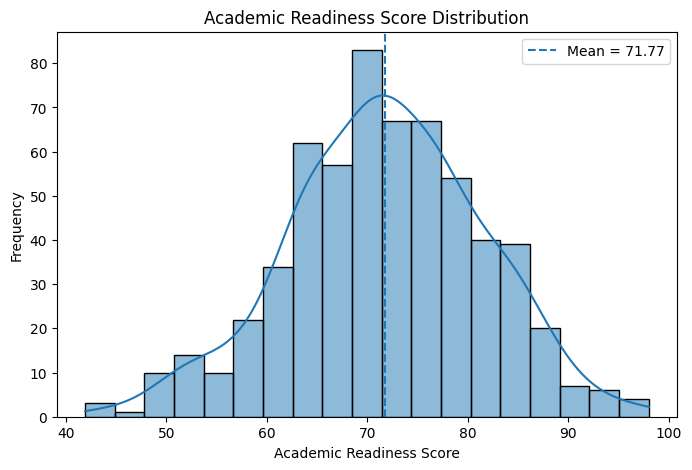

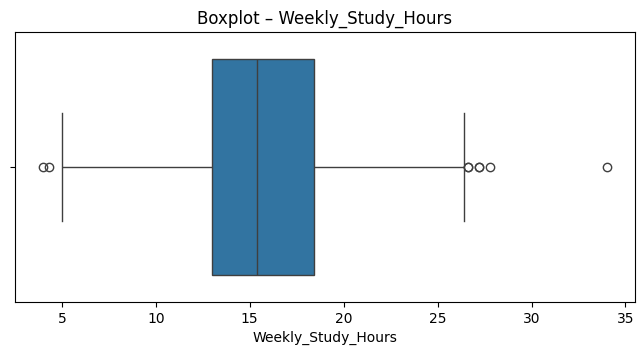

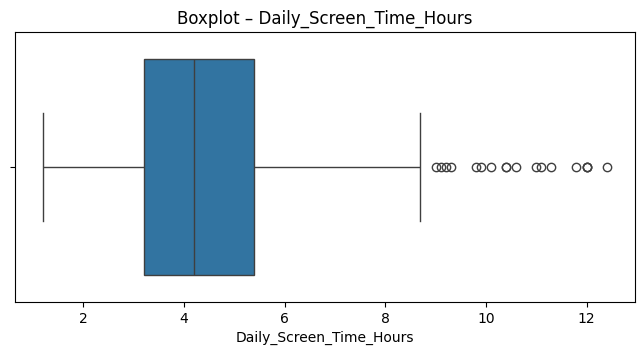

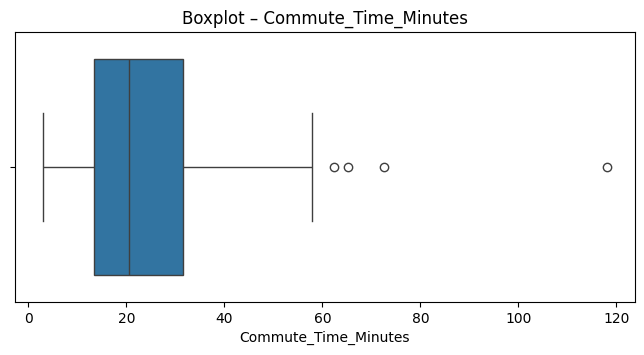

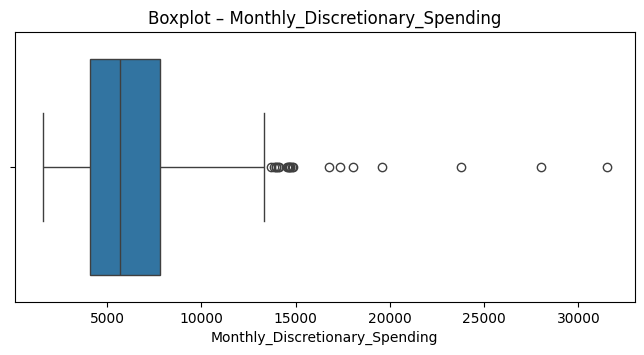

In [12]:
# Distribution of Academic Readiness Score
plt.figure(figsize=(8, 5))
sns.histplot(readiness, kde=True)
plt.axvline(mu, linestyle="--", label=f"Mean = {mu:.2f}")
plt.title("Academic Readiness Score Distribution")
plt.xlabel("Academic Readiness Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Boxplots for IQR outlier variables
for col in outlier_vars:
    plt.figure(figsize=(8, 3.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot – {col}")
    plt.xlabel(col)
    plt.show()


## 12. Five Meaningful Statistical Observations

The following cells generate five observations directly from the calculated results, so the conclusion remains consistent with the supplied dataset.

In [13]:
# Generate five data-based observations
mode_text = desc_stats.loc[greatest_variable, "Mode"]
weekly_mean_before = s.mean()
weekly_median_before = s.median()
weekly_mean_after = filtered.mean()
weekly_median_after = filtered.median()

observations = [
    f"1. {greatest_variable} has the greatest absolute variability among the five requested "
    f"descriptive variables, with a standard deviation of {greatest_sd:.4f}.",
    f"2. Weekly_Study_Hours has a mean of {weekly_mean_before:.4f} and a median of "
    f"{weekly_median_before:.4f} before IQR outlier removal; after removal, the mean is "
    f"{weekly_mean_after:.4f} and the median is {weekly_median_after:.4f}.",
    f"3. The IQR method detected {len(outlier_details['Weekly_Study_Hours'])} outlier(s) in "
    f"Weekly_Study_Hours, {len(outlier_details['Daily_Screen_Time_Hours'])} in "
    f"Daily_Screen_Time_Hours, {len(outlier_details['Commute_Time_Minutes'])} in "
    f"Commute_Time_Minutes, and {len(outlier_details['Monthly_Discretionary_Spending'])} in "
    f"Monthly_Discretionary_Spending.",
    f"4. P(A) = {p_A:.4f}, P(B) = {p_B:.4f}, and P(A and B) = {p_A_and_B:.4f}. "
    f"P(A)×P(B) = {independence_product:.4f}, so A and B "
    f"{'appear approximately independent' if np.isclose(p_A_and_B, independence_product, atol=1e-3) else 'do not appear independent'} "
    f"in this sample.",
    f"5. Academic_Readiness_Score has mean {mu:.4f} and standard deviation {sigma:.4f}. "
    f"The highest score has Z = {highest_z:.4f}, while the lowest has Z = {lowest_z:.4f}; "
    f"these indicate their distances from the average readiness level in standard-deviation units."
]

for obs in observations:
    print(obs)


1. Academic_Readiness_Score has the greatest absolute variability among the five requested descriptive variables, with a standard deviation of 9.6944.
2. Weekly_Study_Hours has a mean of 15.6910 and a median of 15.4000 before IQR outlier removal; after removal, the mean is 15.6029 and the median is 15.3500.
3. The IQR method detected 8 outlier(s) in Weekly_Study_Hours, 18 in Daily_Screen_Time_Hours, 4 in Commute_Time_Minutes, and 20 in Monthly_Discretionary_Spending.
4. P(A) = 0.2533, P(B) = 0.0750, and P(A and B) = 0.0517. P(A)×P(B) = 0.0190, so A and B do not appear independent in this sample.
5. Academic_Readiness_Score has mean 71.7732 and standard deviation 9.6944. The highest score has Z = 2.7054, while the lowest has Z = -3.0815; these indicate their distances from the average readiness level in standard-deviation units.


## Final Conclusion

This analysis covered:

1. Central tendency and dispersion for five wellbeing/academic variables.
2. IQR-based outlier detection for study hours, screen time, commute time, and discretionary spending.
3. The effect of outlier removal on mean and median.
4. Probability of part-time employment, high stress, scholarship, and regular exercise.
5. Union, intersection, and conditional probabilities.
6. Mutual exclusivity of Year 1 and Year 4.
7. Independence assessment using $P(A\cap B)$ versus $P(A)P(B)$.
8. Bayes' theorem verification.
9. Z-score analysis of the highest and lowest Academic Readiness Scores.
10. The 68–95–99.7 empirical rule for the normal distribution.

**Note:** The empirical-rule percentages are theoretical expectations for a normal distribution; they do not assert that the observed dataset itself is perfectly normal.